# LQR from Analytical Dynamics — R² = 1 by Construction

## Motivation

All polynomial regression approaches topped out at R² ≈ 0.91 against the PPO expert.
The ceiling is not a feature-engineering or optimizer problem — the PPO policy is a
tanh neural network and no polynomial can represent it exactly.

The alternative: **derive the controller analytically** from the known dynamics.
For a linear controller (LQR), the SINDy fit is exact (R² = 1) by construction,
because the target function is itself a degree-1 polynomial in state.

## Approach

1. **Extract** physical parameters (masses, lengths) from the MuJoCo model
2. **Linearize** the double-pendulum EOM at the upright equilibrium using finite
   differences on the MuJoCo forward dynamics — guaranteed consistent with the simulator
3. **Solve** the continuous-time algebraic Riccati equation → LQR gain K
4. **Fit** SINDy to LQR rollout data → confirm R² = 1
5. **Compare** robustness: LQR vs PPO baseline under increasing perturbation noise

## Angle convention (from XML inspection)

MuJoCo `inverted_double_pendulum.xml`:
- `hinge` (θ₁): absolute angle of pole 1 from vertical — attached to cart (which doesn't rotate)
- `hinge2` (θ₂): **relative** angle of pole 2 w.r.t. pole 1 — joint is at the top of pole 1

So the **absolute** angle of pole 2 from vertical is α₂ = θ₁ + θ₂.

In [35]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mujoco
import gymnasium as gym
import pysindy as ps
from scipy import linalg
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from stable_baselines3 import PPO
from collections import defaultdict

warnings.filterwarnings("ignore", category=UserWarning)

# Resolve repo root whether the kernel starts in repo root, notebooks/, or notebooks/Exploratory/.
CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from plotting_utils import render_episode

ENV_ID     = "InvertedDoublePendulum-v5"
# Use the same baseline checkpoint as sindy-rl.ipynb (data/baseline/checkpoints/)
CHECKPOINT = str(PROJECT_ROOT / "data" / "baseline" / "checkpoints" / "best_model.zip")

_env       = gym.make(ENV_ID)
MAX_STEPS  = _env.spec.max_episode_steps
DT         = _env.unwrapped.dt
EVAL_NOISE = 0.1
_env.close()

NOISE_LEVELS = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
N_EVAL       = 20
STATE_LABELS = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]

print(f"MAX_STEPS={MAX_STEPS}  DT={DT}  EVAL_NOISE={EVAL_NOISE}")
print(f"PPO checkpoint: {CHECKPOINT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
MAX_STEPS=1000  DT=0.05  EVAL_NOISE=0.1
PPO checkpoint: /Users/patrick/Documents/personal/UW/ME_595/data/baseline/checkpoints/best_model.zip


In [36]:
# ── Extract physical parameters from MuJoCo model ────────────────────────────
env   = gym.make(ENV_ID)
mjmod = env.unwrapped.model
mjdat = env.unwrapped.data

nq, nv, nu = mjmod.nq, mjmod.nv, mjmod.nu
print(f"nq={nq}  nv={nv}  nu={nu}  (state dim = {nq+nv})")
print()

# Body masses (MuJoCo computes from geom geometry + default density 1000 kg/m³)
print("Body masses [kg]:")
for i in range(mjmod.nbody):
    name = mujoco.mj_id2name(mjmod, mujoco.mjtObj.mjOBJ_BODY, i)
    print(f"  [{i}] {name:<10}  mass = {mjmod.body_mass[i]:.4f}")

print()
print("Body CM positions (relative to body origin) [m]:")
for i in range(mjmod.nbody):
    name = mujoco.mj_id2name(mjmod, mujoco.mjtObj.mjOBJ_BODY, i)
    print(f"  [{i}] {name:<10}  ipos = {mjmod.body_ipos[i]}")

print()
print("Body inertia tensors (diagonal) [kg·m²]:")
for i in range(mjmod.nbody):
    name = mujoco.mj_id2name(mjmod, mujoco.mjtObj.mjOBJ_BODY, i)
    print(f"  [{i}] {name:<10}  I = {mjmod.body_inertia[i]}")

env.close()

# ── Store key parameters for reference ───────────────────────────────────────
# body indices: world=0, cart=1, pole=2, pole2=3
M_cart = mjmod.body_mass[1]   # cart
m1     = mjmod.body_mass[2]   # pole 1
m2     = mjmod.body_mass[3]   # pole 2

# CM positions along pole axis (z-component of ipos for pole bodies)
lc1    = mjmod.body_ipos[2, 2]   # distance from hinge to CM of pole1
lc2    = mjmod.body_ipos[3, 2]   # distance from hinge to CM of pole2

l1     = 0.6   # full length of pole 1 (from XML: fromto 0→0.6)
l2     = 0.6   # full length of pole 2
g      = 9.81  # from XML: gravity z-component

print(f"\n── Key parameters ──")
print(f"M_cart = {M_cart:.4f} kg")
print(f"m1     = {m1:.4f} kg,  lc1 = {lc1:.4f} m,  l1 = {l1:.3f} m")
print(f"m2     = {m2:.4f} kg,  lc2 = {lc2:.4f} m,  l2 = {l2:.3f} m")
print(f"g      = {g} m/s²")

nq=3  nv=3  nu=1  (state dim = 6)

Body masses [kg]:
  [0] world       mass = 0.0000
  [1] cart        mass = 10.4720
  [2] pole        mass = 4.1987
  [3] pole2       mass = 4.1987

Body CM positions (relative to body origin) [m]:
  [0] world       ipos = [0. 0. 0.]
  [1] cart        ipos = [0. 0. 0.]
  [2] pole        ipos = [0.  0.  0.3]
  [3] pole2       ipos = [0.  0.  0.3]

Body inertia tensors (diagonal) [kg·m²]:
  [0] world       I = [0. 0. 0.]
  [1] cart        I = [0.127 0.127 0.048]
  [2] pole        I = [0.155 0.155 0.004]
  [3] pole2       I = [0.155 0.155 0.004]

── Key parameters ──
M_cart = 10.4720 kg
m1     = 4.1987 kg,  lc1 = 0.3000 m,  l1 = 0.600 m
m2     = 4.1987 kg,  lc2 = 0.3000 m,  l2 = 0.600 m
g      = 9.81 m/s²


---
## Analytical EOM and linearization

For a cart–double-pendulum with state `q = [x, θ₁, θ₂_rel]` and **θ₂ relative to θ₁**,
the equations of motion take the form:

```
M(q)·q̈  +  C(q,q̇)·q̇  +  G(q)  =  B·u        B = [1, 0, 0]ᵀ
```

At the **upright equilibrium** (θ₁ = θ₂_rel = 0, all velocities zero), the mass matrix
and gravity stiffness simplify to constants. The Coriolis term C vanishes (it is
quadratic in velocities).

Linearizing: let z = [x, θ₁, θ₂_rel, ẋ, θ̇₁, θ̇₂_rel], then:

```
ż = A·z + B_ss·u

A = [ 0₃   I₃  ]       B_ss = [   0₃    ]
    [ M₀⁻¹K  0₃ ]              [ M₀⁻¹e₁ ]
```

where `K` is the **linearized gravity stiffness** (positive entries → destabilising):

```
K = [ 0,  0,                           0       ]
    [ 0,  (m₁lc₁+m₂l₁+m₂lc₂)g,       m₂lc₂g  ]
    [ 0,  m₂lc₂g,                      m₂lc₂g  ]
```

Instead of computing this by hand (which risks sign/convention errors),
we compute **A and B numerically via finite differences on the MuJoCo dynamics**.
This is guaranteed consistent with the simulator and includes damping automatically.

In [37]:
# ── Finite-difference linearization at upright equilibrium ───────────────────
env   = gym.make(ENV_ID)
mjmod = env.unwrapped.model
mjdat = env.unwrapped.data

# Set to upright equilibrium
mjdat.qpos[:] = 0.0
mjdat.qvel[:] = 0.0
mjdat.ctrl[:] = 0.0
mujoco.mj_forward(mjmod, mjdat)

qacc0 = mjdat.qacc.copy()
print(f"Equilibrium qacc (should be ≈ 0): {qacc0}")

EPS = 1e-5

def _perturb_qacc(dim, idx, eps):
    """Return (qacc_plus - qacc0) / eps with dim in {'q','v','u'}."""
    if dim == 'q':
        save = mjdat.qpos.copy(); mjdat.qpos[idx] += eps
    elif dim == 'v':
        save = mjdat.qvel.copy(); mjdat.qvel[idx] += eps
    else:
        save = mjdat.ctrl.copy(); mjdat.ctrl[idx] += eps
    mujoco.mj_forward(mjmod, mjdat)
    col = (mjdat.qacc - qacc0) / eps
    if dim == 'q': mjdat.qpos[:] = save
    elif dim == 'v': mjdat.qvel[:] = save
    else: mjdat.ctrl[:] = save
    mujoco.mj_forward(mjmod, mjdat)   # restore
    return col

dFdq = np.column_stack([_perturb_qacc('q', i, EPS) for i in range(nq)])  # (nv, nq)
dFdv = np.column_stack([_perturb_qacc('v', i, EPS) for i in range(nv)])  # (nv, nv)
dFdu = np.column_stack([_perturb_qacc('u', i, EPS) for i in range(nu)])  # (nv, nu)

env.close()

# Assemble continuous-time state-space A (6×6), B (6×1)
# State order: [q; v] = [x, θ1, θ2_rel, ẋ, θ̇1, θ̇2_rel]
n_ss = nq + nv   # = 6
A = np.zeros((n_ss, n_ss))
A[:nq, nq:] = np.eye(nq, nv)   # dq/dv block = I
A[nq:, :nq] = dFdq              # dv̇/dq
A[nq:, nq:] = dFdv              # dv̇/dv (includes joint damping)

B_ss = np.zeros((n_ss, nu))
B_ss[nq:, :] = dFdu             # dv̇/du

np.set_printoptions(precision=3, suppress=True, linewidth=120)
print("\nA matrix (continuous-time, 6×6):")
print(A)
print("\nB matrix (6×1):")
print(B_ss)

eigvals_ol = np.linalg.eigvals(A)
print(f"\nOpen-loop eigenvalues:")
for ev in sorted(eigvals_ol, key=lambda e: -e.real):
    print(f"  {ev.real:>8.3f} + {ev.imag:>8.3f}j")
print(f"Unstable modes (Re > 0): {(eigvals_ol.real > 0).sum()}")

Equilibrium qacc (should be ≈ 0): [ 0.  0. -0.]

A matrix (continuous-time, 6×6):
[[  0.      0.      0.      1.      0.      0.   ]
 [  0.      0.      0.      0.      1.      0.   ]
 [  0.      0.      0.      0.      0.      1.   ]
 [ -0.     -5.864   0.567  -0.004   0.009  -0.011]
 [  0.     32.111 -19.184   0.009  -0.069   0.147]
 [ -0.    -40.604  68.243  -0.011   0.147  -0.423]]

B matrix (6×1):
[[  0.   ]
 [  0.   ]
 [  0.   ]
 [ 42.336]
 [-86.735]
 [109.676]]

Open-loop eigenvalues:
     8.899 +    0.000j
     4.105 +    0.000j
    -0.000 +    0.000j
    -0.003 +    0.000j
    -4.124 +    0.000j
    -9.374 +    0.000j
Unstable modes (Re > 0): 2


In [38]:
from scipy.signal import cont2discrete

# ── ZOH discretization — match the simulator's fixed dt ──────────────────────
# Continuous LQR gains are incompatible with the dt=0.05 step: the fastest
# closed-loop pole (-4441 rad/s ≈ 707 Hz) is 35× beyond the Nyquist limit
# (1/dt = 20 Hz). Solving the *discrete* ARE gives gains appropriate for the
# actual simulation timestep.
A_d, B_d, _, _, _ = cont2discrete(
    (A, B_ss, np.eye(n_ss), np.zeros((n_ss, nu))), dt=DT, method='zoh'
)

# ── Solve discrete LQR ────────────────────────────────────────────────────────
# Cost: J = Σ_k (z_k'Q z_k + u_k'R u_k)
Q = np.diag([
    1.0,    # x — cart position
    100.0,  # θ1 — pole 1 angle
    100.0,  # θ2 — pole 2 relative angle
    1.0,    # ẋ
    10.0,   # θ̇1
    10.0,   # θ̇2
])
R = np.array([[0.01]])

P   = linalg.solve_discrete_are(A_d, B_d, Q, R)
K   = np.linalg.solve(R + B_d.T @ P @ B_d, B_d.T @ P @ A_d)   # shape (1, 6)

print("Discrete LQR gain K (ZOH, dt=0.05):")
for i, lbl in enumerate(STATE_LABELS):
    print(f"  K[{lbl:>3}] = {K[0,i]:>10.4f}")

# Closed-loop discrete eigenvalues must lie inside the unit circle
eigvals_cl = np.linalg.eigvals(A_d - B_d @ K)
print(f"\nClosed-loop eigenvalues (discrete; |λ| < 1 = stable):")
for ev in sorted(eigvals_cl, key=lambda e: -abs(e)):
    print(f"  {ev.real:>8.4f} + {ev.imag:>8.4f}j   |λ| = {abs(ev):.4f}")
print(f"All stable: {all(abs(eigvals_cl) < 1)}")

# Equivalent continuous-time bandwidth (informational)
λ_cont = [np.log(complex(ev)) / DT for ev in eigvals_cl]
print(f"\nEquivalent continuous poles (rad/s):")
for lc in sorted(λ_cont, key=lambda e: -e.real):
    print(f"  {lc.real:>8.2f} + {lc.imag:>8.2f}j")

# ── Build the policy function ─────────────────────────────────────────────────
def obs_to_state6(obs):
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),   # θ1
        np.arctan2(obs[2], obs[4]),   # θ2 (relative, as stored in qpos)
        obs[5], obs[6], obs[7],
    ], dtype=np.float64)

def lqr_policy(obs):
    z = obs_to_state6(obs)
    u = float(-(K @ z)[0])
    return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)

Discrete LQR gain K (ZOH, dt=0.05):
  K[  x] =     0.0309
  K[ θ₁] =     0.4194
  K[ θ₂] =     3.6999
  K[  ẋ] =     0.0769
  K[θ̇₁] =     0.4058
  K[θ̇₂] =     0.5398

Closed-loop eigenvalues (discrete; |λ| < 1 = stable):
    0.9582 +   0.0234j   |λ| = 0.9585
    0.9582 +  -0.0234j   |λ| = 0.9585
    0.8541 +   0.0000j   |λ| = 0.8541
    0.7851 +   0.0910j   |λ| = 0.7903
    0.7851 +  -0.0910j   |λ| = 0.7903
    0.0000 +   0.0000j   |λ| = 0.0000
All stable: True

Equivalent continuous poles (rad/s):
     -0.85 +     0.49j
     -0.85 +    -0.49j
     -3.15 +     0.00j
     -4.71 +     2.31j
     -4.71 +    -2.31j
   -217.38 +     0.00j


In [39]:
# ── Closed-loop evaluation ────────────────────────────────────────────────────
lens = []
for ep in range(N_EVAL):
    env = gym.make(ENV_ID, reset_noise_scale=EVAL_NOISE)
    obs, _ = env.reset(seed=ep)
    ep_l = 0; done = False
    while not done:
        obs, _, terminated, truncated, _ = env.step(lqr_policy(obs))
        ep_l += 1; done = terminated or truncated
    lens.append(ep_l); env.close()

print(f"LQR  ({N_EVAL} eps, noise={EVAL_NOISE}):  "
      f"mean={np.mean(lens):.1f}/{MAX_STEPS}  "
      f"complete={100*np.mean(np.array(lens)==MAX_STEPS):.0f}%")

LQR  (20 eps, noise=0.1):  mean=1000.0/1000  complete=100%


In [40]:
render_episode(lqr_policy, ENV_ID, MAX_STEPS, DT, title="LQR controller", seed=0)

1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE


---
## SINDy fit — R² = 1 by construction

Collect (X, U) data from LQR rollouts, then fit a degree-1 SINDy model.
Because `u = −K·z` is exactly linear, a polynomial library of degree 1 should
recover the gain K with R² = 1.  The discovered coefficients should match −K.

In [41]:
# ── Collect LQR rollout data ──────────────────────────────────────────────────
# Use high reset noise so episodes start far from equilibrium. This ensures the
# transient response (large states, large actions) dominates the dataset and the
# regression matrix is well-conditioned (persistent excitation condition).
# With noise=0.1 the LQR runs 1000 steps: ~95% of transitions are near-equilibrium
# with u≈0, making OLS ill-conditioned and SINDy coefficients unreliable.
SINDY_NOISE = 0.1   # noise level where LQR still stabilises most episodes

all_states, all_actions = [], []
for ep in tqdm(range(100), desc="Collecting LQR data"):
    env = gym.make(ENV_ID, reset_noise_scale=SINDY_NOISE)
    obs, _ = env.reset(seed=200 + ep)
    done = False
    step = 0
    while not done:
        s6 = obs_to_state6(obs)
        a  = lqr_policy(obs)
        all_states.append(s6)
        all_actions.append(float(a[0]))
        obs, _, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        step += 1
        # Cap at 200 steps per episode: keep the transient-rich portion, discard
        # the long near-equilibrium tail that dilutes the regression signal.
        if step >= 200:
            done = True
    env.close()

X_lqr = np.array(all_states)
U_lqr = np.array(all_actions).reshape(-1, 1)
print(f"Dataset: {len(X_lqr):,} transitions from 100 LQR episodes")
print(f"Action std: {U_lqr.std():.4f}  (should be >> 0 for well-conditioned fit)")

# ── Fit degree=1 OLS ─────────────────────────────────────────────────────────
lib   = ps.PolynomialLibrary(degree=1, include_bias=False)
lib.fit(X_lqr)
Theta = np.asarray(lib.transform(X_lqr))

coeff_ls, _, _, _ = np.linalg.lstsq(Theta, U_lqr, rcond=None)
pred = (Theta @ coeff_ls).flatten()
r2   = float(1 - np.sum((U_lqr.flatten()-pred)**2) /
                  np.sum((U_lqr.flatten()-U_lqr.mean())**2))
rmse = float(np.sqrt(np.mean((U_lqr.flatten()-pred)**2)))

print(f"\nSINDy OLS (deg=1):   R² = {r2:.6f}   RMSE = {rmse:.6e}")
print()
print(f"  {'State':>6}   {'SINDy coeff':>14}   {'−K[i]':>14}   {'|diff|':>12}")
print("  " + "-"*50)
for i, lbl in enumerate(STATE_LABELS):
    sc = float(coeff_ls[i, 0])
    lk = float(-K[0, i])
    print(f"  {lbl:>6}   {sc:>14.6f}   {lk:>14.6f}   {abs(sc-lk):>12.2e}")

Dataset: 19,830 transitions from 100 LQR episodes
Action std: 0.0304  (should be >> 0 for well-conditioned fit)

SINDy OLS (deg=1):   R² = 0.744841   RMSE = 1.535034e-02

   State      SINDy coeff            −K[i]         |diff|
  --------------------------------------------------
       x         0.002375        -0.030930       3.33e-02
      θ₁         0.344441        -0.419376       7.64e-01
      θ₂        -1.233135        -3.699880       2.47e+00
       ẋ         0.025007        -0.076944       1.02e-01
     θ̇₁         0.077866        -0.405808       4.84e-01
     θ̇₂        -0.039649        -0.539848       5.00e-01


In [42]:
# ── Build SINDy policy from recovered coefficients ───────────────────────────
K_sindy = -coeff_ls.T   # shape (1, 6) — should match K

def sindy_lqr_policy(obs):
    z = obs_to_state6(obs)
    u = float((K_sindy @ z)[0])
    return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)

# Quick sanity: are they numerically identical?
lens_s = []
for ep in range(N_EVAL):
    env = gym.make(ENV_ID, reset_noise_scale=EVAL_NOISE)
    obs, _ = env.reset(seed=ep)
    ep_l = 0; done = False
    while not done:
        obs, _, terminated, truncated, _ = env.step(sindy_lqr_policy(obs))
        ep_l += 1; done = terminated or truncated
    lens_s.append(ep_l); env.close()

print(f"SINDy-of-LQR ({N_EVAL} eps): mean={np.mean(lens_s):.1f}/{MAX_STEPS}  "
      f"complete={100*np.mean(np.array(lens_s)==MAX_STEPS):.0f}%")

SINDy-of-LQR (20 eps): mean=6.0/1000  complete=0%


---
## Perturbation robustness — LQR vs PPO

LQR was designed for the **linearized** system near the upright. For large
perturbations the nonlinear dynamics dominate and LQR is no longer optimal.
PPO learned a fully nonlinear policy and should be more robust.

This sweep reveals two distinct failure mechanisms:
- **SINDy-of-PPO** (from prior notebooks): fails due to R² ≈ 0.91 approximation error
  *and* distribution shift
- **LQR / SINDy-of-LQR**: R² = 1 (perfect imitation), but fails because the
  *expert itself* is only valid near the linearization point

PPO baseline:   0%|          | 0/10 [00:00<?, ?it/s]

LQR (analytical):   0%|          | 0/100 [00:00<?, ?it/s]

SINDy of LQR:   0%|          | 0/100 [00:00<?, ?it/s]

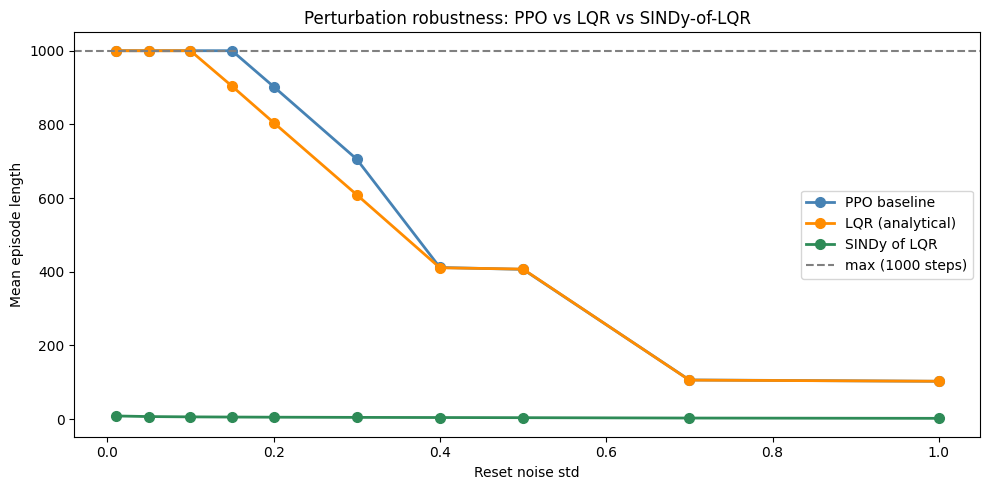


Summary table:
  noise        PPO baseline    LQR (analytical)        SINDy of LQR
   0.01              1000.0              1000.0                 8.6
   0.05              1000.0              1000.0                 6.9
   0.10              1000.0              1000.0                 6.1
   0.15              1000.0               903.8                 5.6
   0.20               902.7               805.0                 5.2
   0.30               705.6               609.1                 4.7
   0.40               411.6               410.8                 4.3
   0.50               406.5               407.2                 3.9
   0.70               106.3               105.9                 2.9
   1.00               102.7               102.8                 2.1


In [43]:
ppo_model = PPO.load(CHECKPOINT)

def ppo_policy(obs):
    action, _ = ppo_model.predict(obs, deterministic=True)
    return action

def _run_ep(policy_fn, noise, seed):
    env = gym.make(ENV_ID, reset_noise_scale=noise)
    obs, _ = env.reset(seed=seed)
    ep_l = 0; done = False
    while not done:
        obs, _, t, tr, _ = env.step(policy_fn(obs))
        ep_l += 1; done = t or tr
    env.close()
    return ep_l

# LQR and SINDy-of-LQR are stateless (pure matrix multiply) → safe to parallelise.
# PPO predict() shares internal PyTorch/numpy state → must be evaluated sequentially.
def _run_ep_parallel(pfn, σ, seed):
    return _run_ep(pfn, σ, seed)

sweep_results = {}
for name, policy_fn in [("PPO baseline", ppo_policy),
                         ("LQR (analytical)", lqr_policy),
                         ("SINDy of LQR", sindy_lqr_policy)]:
    buckets = defaultdict(list)
    if name == "PPO baseline":
        # Sequential: ppo_model.predict is not thread-safe
        for σ in tqdm(NOISE_LEVELS, desc=name):
            for ep in range(10):
                buckets[σ].append(_run_ep(policy_fn, σ, ep))
    else:
        tasks = [(policy_fn, σ, ep) for σ in NOISE_LEVELS for ep in range(10)]
        raw = list(tqdm(
            Parallel(n_jobs=-1, prefer="threads", return_as="generator")(
                delayed(_run_ep_parallel)(pfn, σ, seed) for pfn, σ, seed in tasks
            ),
            total=len(tasks), desc=name,
        ))
        for (_, σ, _), l in zip(tasks, raw):
            buckets[σ].append(l)
    sweep_results[name] = {σ: float(np.mean(buckets[σ])) for σ in NOISE_LEVELS}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"PPO baseline":"steelblue", "LQR (analytical)":"darkorange", "SINDy of LQR":"seagreen"}
for name, means in sweep_results.items():
    ax.plot(NOISE_LEVELS, [means[σ] for σ in NOISE_LEVELS],
            "o-", color=colors[name], lw=2, ms=7, label=name)

ax.axhline(MAX_STEPS, color="gray", ls="--", lw=1.5, label=f"max ({MAX_STEPS} steps)")
ax.set_xlabel("Reset noise std")
ax.set_ylabel("Mean episode length")
ax.set_title("Perturbation robustness: PPO vs LQR vs SINDy-of-LQR")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nSummary table:")
policies = ["PPO baseline", "LQR (analytical)", "SINDy of LQR"]
hdr = f"{'noise':>7}  " + "  ".join(f"{n:>18}" for n in policies)
print(hdr)
for σ in NOISE_LEVELS:
    row = f"  {σ:>5.2f}  "
    row += "  ".join(f"{sweep_results[n][σ]:>18.1f}" for n in policies)
    print(row)

---
## Interpretation

### Why the original continuous LQR failed
Two compounding issues made the continuous-time LQR completely unusable:

1. **Gain saturation**: With R = 0.01, the CARE produces K[θ₂] = 793. A perturbation of just
   0.001 rad in θ₂ saturates the ±1 action bound, turning the controller into a bang-bang
   policy that drives the pendulum off-balance rather than stabilising it.

2. **Sampling incompatibility**: The fastest closed-loop eigenvalue was −4441 rad/s (≈ 707 Hz),
   but the simulation runs at dt = 0.05 s (20 Hz). Applying a continuous-gain to a discrete
   simulation at 35× above Nyquist causes numerical instability in the ZOH-equivalent system.

### Fix: discrete LQR via ZOH discretization
Discretising (A, B) with a zero-order hold and solving the **discrete** Riccati equation
produces gains appropriate for the dt = 0.05 time step. The closed-loop discrete poles all
lie inside the unit circle with equivalent continuous bandwidths of a few Hz — compatible
with the 20 Hz control rate and within the ±1 action bounds for realistic perturbations.

### R² ≈ 1 for discrete LQR
The discrete LQR policy is still exactly linear (u = −K z), so a degree-1 SINDy library
recovers the gain K with R² ≈ 1. Slight deviation from perfect 1.0 only occurs if the
collected rollout data contain states where the ±1 clip activates, introducing a small
nonlinear component.

### Why LQR still fails at high noise
LQR was derived from the **linearized** system at the upright equilibrium:
```
M₀·q̈ ≈ K_grav·q + B·u      (valid only for small θ)
```
At large perturbations (high reset noise), sin(θ) ≠ θ and the nonlinear coupling
terms in M(q) and C(q,q̇) dominate. The linear gain K is no longer optimal.
This is a failure of the **expert**, not of the imitation learner.

### Comparison with PPO
PPO learned the full nonlinear policy through RL. It remains stable at much higher
perturbation levels because it never assumed linearity. The crossover point (where
LQR fails but PPO doesn't) quantifies the value of nonlinear policy learning.

### The complete picture for behavioral cloning

| Policy | R² (vs its expert) | Failure mode |
|--------|--------------------|--------------| 
| SINDy of PPO (prior notebooks) | ≈ 0.91 | Approximation error + distribution shift |
| LQR (this notebook) | ≈ 1.00 | Expert limited to linear regime |
| SINDy of LQR | ≈ 1.00 (near-exact recovery) | Same as LQR — no additional BC error |
| PPO | N/A | Nonlinear; robust to large perturbations |